# Week 35, Tuesday session: Ridge and Lasso in practice

**FYS-STK3155/4155 — Applied Data Analysis and Machine Learning, fall 2026**

This is the companion notebook for the Tuesday flipped-classroom session of week 35
(see the slides `week35tuesday.pdf`). The format for the Tuesday sessions, weeks 35–48:

1. **First ~20 minutes:** open questions from Monday's lecture, then the warm-up
   questions below, discussed with your neighbours and in plenum.
2. **Rest of the double session:** the four cases below, worked in pairs or small
   groups. We circulate and help; short plenary wrap-ups between cases.
3. **Last 5 minutes:** what to finish before the exercise deadline (Friday at
   midnight), and what Monday next week builds on.

Everything here reuses the running examples from the lectures and feeds
directly into this week's exercise set and Project 1. Reading: the book, Chapter 3,
Sections 3.5, 3.7–3.10 and 3.13. The notebook also contains the code behind two
figures shown in Monday's lecture: the exercise-3 train/test figure and the plot
of Eqs. (3.60), (3.61) and (3.63).

## Warm-up questions (discuss before touching the keyboard)

**Warm-up 1 — the one-sentence summaries.** Complete each sentence from Monday, in
one line each, without notes:

* (a) Gauss–Markov says OLS is optimal among …
* (b) Ridge beats OLS in mean squared error because …
* (c) the Lasso, unlike Ridge, can …
* (d) before applying any penalty, the features must be …

**Warm-up 2 — read the formula.** The Ridge fit shrinks the coordinate of
$\boldsymbol{y}$ along $\boldsymbol{u}_i$ by $\sigma_i^2/(\sigma_i^2+\lambda)$.
For a badly conditioned degree-10 Vandermonde matrix, which directions are affected
first as $\lambda$ grows, and why is that exactly what we want?

**Warm-up 3 — predict before you compute.** In Case 2 you will fit the degree-5
polynomial with Ridge for $\lambda\in\{0, 10^{-4}, 10^{-2}, 1, 100\}$. Before
running anything, sketch what you expect for (a) $\|\hat{\boldsymbol\theta}\|_2$,
(b) the training MSE, (c) the test MSE, as functions of $\lambda$.

*Answers are collected at the very end of the notebook — no peeking until the
plenary discussion.*

In [1]:
# Setup: run this first
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

rng = np.random.default_rng(2026)

def MSE(y_data, y_model):
    return np.mean((y_data - y_model) ** 2)

def R2(y_data, y_model):
    return 1.0 - np.sum((y_data - y_model) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)

# The degree-5 running example from the lectures
n = 100
x = np.linspace(0, 1, n)
y = 2.0 + 3.0 * x - 5.0 * x**2 + np.exp(-x) + 0.1 * rng.standard_normal(n)
X = np.vander(x, 6, increasing=True)          # columns 1, x, x^2, ..., x^5
print("X shape:", X.shape)

X shape: (100, 6)


## The exercise-3 figure from Monday's lecture

Monday's lecture opened with the result of exercise 3 of this week's set:
training and test MSE for polynomial fits of degree 1 to 15 (the reproduction of
Figure 2.11 of Hastie et al.). Here is the exact code that produced that figure
— run it, then rerun it **without** the fixed seeds and watch which features of
the figure are robust and which move around.

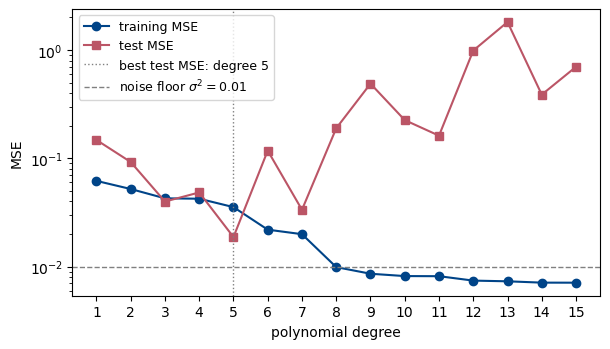

best test MSE 0.01873 at degree 5; training MSE at degree 15: 0.00710 (below the noise floor!)


In [2]:
from sklearn.model_selection import train_test_split

# Fresh generator with the lecture's seed, so this cell reproduces the
# lecture figure exactly; remove the seeds to get a new realisation.
rng_ex3 = np.random.default_rng(2026)
n3 = 100
x3 = np.linspace(-3, 3, n3)
y3 = np.exp(-x3**2) + 1.5 * np.exp(-(x3 - 2)**2) + rng_ex3.normal(0, 0.1, n3)
x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.3,
                                                        random_state=2026)

degrees = np.arange(1, 16)
mse3_train, mse3_test = [], []
for d in degrees:
    Xtr = np.vander(x3_train, d + 1, increasing=True)
    Xte = np.vander(x3_test,  d + 1, increasing=True)
    theta = np.linalg.lstsq(Xtr, y3_train, rcond=None)[0]   # SVD based
    mse3_train.append(MSE(y3_train, Xtr @ theta))
    mse3_test.append(MSE(y3_test,  Xte @ theta))

best_d = degrees[int(np.argmin(mse3_test))]
plt.figure(figsize=(6.2, 3.6))
plt.plot(degrees, mse3_train, "o-", color="#004488", label="training MSE")
plt.plot(degrees, mse3_test, "s-", color="#BB5566", label="test MSE")
plt.axvline(best_d, color="gray", ls=":", lw=1, label=f"best test MSE: degree {best_d}")
plt.axhline(0.1**2, color="gray", ls="--", lw=1, label=r"noise floor $\sigma^2=0.01$")
plt.xlabel("polynomial degree"); plt.ylabel("MSE"); plt.yscale("log")
plt.xticks(degrees); plt.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f"best test MSE {min(mse3_test):.5f} at degree {best_d}; "
      f"training MSE at degree 15: {mse3_train[-1]:.5f} (below the noise floor!)")

**Discussion (from Monday, continued here).**

* Why can the training MSE never increase when the degree grows?
* The training MSE dips *below* the noise floor $\sigma^2$ at high degree — what
  is the model "learning" there?
* Rerun without seeds a few times, and with $n=30$ and $n=1000$: which curve
  moves, and in which direction? Where is underfitting, where overfitting?

Case 4 below extends this figure: the degree fixed at 15, with Ridge's $\lambda$
as the complexity dial instead.

## The three estimators plotted: Eqs. (3.60), (3.61) and (3.63)

The second figure from Monday. On the identity design $\boldsymbol{X}=\boldsymbol{I}$
the three methods solve $p$ decoupled scalar problems, with the closed forms

$$
\hat\theta_i^{\mathrm{OLS}} = y_i \;\;(3.60), \qquad
\hat\theta_i^{\mathrm{Ridge}} = \frac{y_i}{1+\lambda} \;\;(3.61), \qquad
\hat\theta_i^{\mathrm{Lasso}} = \mathrm{sgn}(y_i)\max\!\left(|y_i|-\tfrac{\lambda}{2},\,0\right) \;\;(3.63).
$$

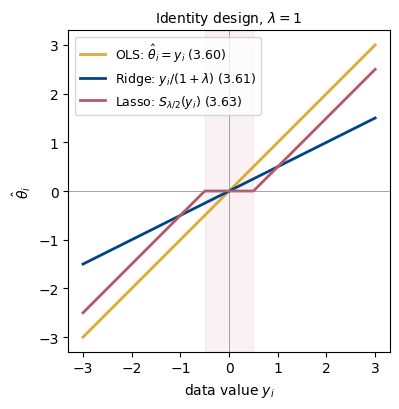

In [3]:
lmbda = 1.0
yv = np.linspace(-3, 3, 601)
ols_est   = yv                                                   # Eq. (3.60)
ridge_est = yv / (1.0 + lmbda)                                   # Eq. (3.61)
lasso_est = np.sign(yv) * np.maximum(np.abs(yv) - lmbda/2., 0.)  # Eq. (3.63)

fig, ax = plt.subplots(figsize=(6.0, 4.2))
ax.plot(yv, ols_est, color="#DDAA33", lw=2, label=r"OLS: $\hat\theta_i=y_i$ (3.60)")
ax.plot(yv, ridge_est, color="#004488", lw=2,
        label=r"Ridge: $y_i/(1+\lambda)$ (3.61)")
ax.plot(yv, lasso_est, color="#BB5566", lw=2,
        label=r"Lasso: $S_{\lambda/2}(y_i)$ (3.63)")
ax.axvspan(-lmbda/2, lmbda/2, color="#BB5566", alpha=0.08)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(r"data value $y_i$"); ax.set_ylabel(r"$\hat\theta_i$")
ax.set_title(r"Identity design, $\lambda=1$", fontsize=10)
ax.legend(fontsize=9, loc="upper left"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

**Discussion.** OLS is the identity — the coefficient reproduces the data,
noise included. Ridge *rotates* the line down: every coefficient, large or
small, is multiplied by $1/(1+\lambda)$, and none ever reaches zero. The Lasso
*translates* the line towards zero and clips it: a dead zone $|y_i|\le\lambda/2$
where the coefficient vanishes exactly, and a constant bias $\lambda/2$ on the
survivors. Note the behaviour for large $|y_i|$: the Lasso subtracts a constant
rather than a fraction, so it distorts strong signals *less* than Ridge, while
removing weak ones entirely.

*Try it:* vary $\lambda$ and replot. Which $\lambda$ makes Ridge and Lasso agree
at $y_i = 2$? Can they ever agree for all $y_i$ at once?

## Case 1: Section 3.13 live — scaling and the intercept in OLS, Ridge and Lasso

A second-order polynomial, simple enough that every coefficient is
interpretable: the data are $y = 2 + 5x^2 + \varepsilon$, so we know what the
intercept *should* be. We fit it with OLS, Ridge and Lasso — scaled and
unscaled, intercept penalised and not — and watch what the choices do. For
Ridge and Lasso a change of units is a **change of model** unless you
standardise, and a penalised intercept quietly changes what the model means.

In [4]:
# The second-order example, and two helper fits
n1 = 100
x1 = rng.random(n1)                              # x in [0, 1]
y1 = 2.0 + 5.0 * x1**2 + 0.1 * rng.standard_normal(n1)
X1 = np.column_stack([np.ones(n1), x1, x1**2])   # intercept, x, x^2

def ridge_closed_form(X, y, lmbda):
    """Solves min ||y - X theta||^2 + lambda ||theta||^2 -- penalises ALL columns."""
    return np.linalg.solve(X.T @ X + lmbda * np.eye(X.shape[1]), X.T @ y)

def fit_scaled_unpenalised_intercept(X_slopes, y, fit_centred):
    """Standardise the slope columns, centre y, fit, recover the intercept."""
    x_mean = X_slopes.mean(axis=0); y_mean = y.mean()
    x_std = X_slopes.std(axis=0)
    theta = fit_centred((X_slopes - x_mean) / x_std, y - y_mean)
    theta = theta / x_std                        # back to raw feature units
    theta_0 = y_mean - x_mean @ theta            # Eq. (3.intercept)
    return theta_0, theta

# --- 1. OLS: the intercept is just another column -------------------------
theta_ols = np.linalg.lstsq(X1, y1, rcond=None)[0]
th0_c, th_c = fit_scaled_unpenalised_intercept(X1[:, 1:], y1,
               lambda Xc, yc: np.linalg.lstsq(Xc, yc, rcond=None)[0])
pred_a = X1 @ theta_ols
pred_b = th0_c + X1[:, 1:] @ th_c
print("OLS with intercept column :", np.round(theta_ols, 4), " (true: 2, 0, 5)")
print("OLS centred + recovered   :", np.round(np.r_[th0_c, th_c], 4))
print("max |prediction difference|:", np.max(np.abs(pred_a - pred_b)))

# units: x -> 1000 x ("millimetres")
X1mm = np.column_stack([np.ones(n1), 1000*x1, (1000*x1)**2])
theta_mm = np.linalg.lstsq(X1mm, y1, rcond=None)[0]
print("\nOLS on millimetre columns :", theta_mm, " (coefficients rescale...)")
print("max |prediction change|    :",
      np.max(np.abs(X1mm @ theta_mm - pred_a)), " (...predictions do not)")

OLS with intercept column : [2.0210e+00 2.5000e-03 4.9448e+00]  (true: 2, 0, 5)
OLS centred + recovered   : [2.0210e+00 2.5000e-03 4.9448e+00]
max |prediction difference|: 2.6645352591003757e-15

OLS on millimetre columns : [2.02099210e+00 2.53929949e-06 4.94480953e-06]  (coefficients rescale...)
max |prediction change|    : 5.329070518200751e-15  (...predictions do not)


In [5]:
# --- 2. Ridge: penalising the intercept vs not ----------------------------
# The cleanest diagnostic: shift all targets by +100.  A model with an honest
# intercept simply shifts with the data; a penalised intercept refuses.
for lmbda in [0.1, 10.0, 1000.0]:
    naive = ridge_closed_form(X1, y1, lmbda)                 # intercept penalised
    naive_shift = ridge_closed_form(X1, y1 + 100.0, lmbda)
    th0, th = fit_scaled_unpenalised_intercept(X1[:, 1:], y1,
               lambda Xc, yc: ridge_closed_form(Xc, yc, lmbda))
    th0s, ths = fit_scaled_unpenalised_intercept(X1[:, 1:], y1 + 100.0,
               lambda Xc, yc: ridge_closed_form(Xc, yc, lmbda))
    shift_naive  = np.mean(X1 @ naive_shift - X1 @ naive)
    shift_proper = np.mean((th0s + X1[:, 1:] @ ths) - (th0 + X1[:, 1:] @ th))
    print(f"lambda = {lmbda:>6}: prediction shift after y -> y + 100:  "
          f"naive {shift_naive:8.3f}   proper {shift_proper:8.3f}   (should be 100)")

lambda =    0.1: prediction shift after y -> y + 100:  naive   99.901   proper  100.000   (should be 100)
lambda =   10.0: prediction shift after y -> y + 100:  naive   91.977   proper  100.000   (should be 100)
lambda = 1000.0: prediction shift after y -> y + 100:  naive   11.847   proper  100.000   (should be 100)


In [6]:
# --- 3. Lasso: same comparison, plus what raw units do to selection -------
from sklearn.linear_model import Lasso

lmbda = 0.5
# (a) naive: intercept column in X, penalised (fit_intercept=False), raw columns
lasso_naive = Lasso(alpha=lmbda/2, fit_intercept=False, max_iter=100000).fit(X1, y1)
# (b) proper: standardised slope columns, sklearn handles the (unpenalised) intercept
Xs1 = (X1[:, 1:] - X1[:, 1:].mean(axis=0)) / X1[:, 1:].std(axis=0)
lasso_proper = Lasso(alpha=lmbda/2, fit_intercept=True, max_iter=100000).fit(Xs1, y1)
print("naive  (intercept penalised, raw)   :", np.round(lasso_naive.coef_, 4))
print("proper (standardised, free intercept): intercept",
      np.round(lasso_proper.intercept_, 4), " slopes", np.round(lasso_proper.coef_, 4))

# raw 'millimetre' columns, penalised intercept: watch who survives
lasso_mm = Lasso(alpha=lmbda/2, fit_intercept=False, max_iter=500000).fit(X1mm, y1)
print("naive on millimetre columns          :", lasso_mm.coef_)
print("  -> columns are [1, 1000x, (1000x)^2]; the penalty now acts in units,")
print("     and the huge-scale columns get near-zero coefficients that escape it")

naive  (intercept penalised, raw)   : [1.7378 3.2874 0.    ]
proper (standardised, free intercept): intercept 3.6154  slopes [0.     1.1567]
naive on millimetre columns          : [ 0.00000000e+00  8.38159160e-03 -2.24823827e-06]
  -> columns are [1, 1000x, (1000x)^2]; the penalty now acts in units,
     and the huge-scale columns get near-zero coefficients that escape it


**Discussion (Case 1) — the role of the intercept.**

* **OLS**: the intercept is just another column. Fitting it directly or by
  centring-and-recovering gives *identical predictions*, and a change of units
  rescales coefficients while leaving predictions untouched: OLS is equivariant,
  scaling is optional cosmetics.
* **Ridge**: the shift experiment is the tell. The properly handled intercept
  follows $y \to y+100$ exactly, for every $\lambda$; the penalised intercept
  increasingly refuses as $\lambda$ grows — the fit is dragged towards zero
  instead of towards the level of the data. The intercept encodes *where the
  data live*, and that is not something we have any reason to believe is small.
* **Lasso**: same story, plus selection. On raw columns the penalty acts in
  units — with "millimetre" columns the coefficients on the huge-scale features
  are numerically tiny and nearly free, while honest-sized coefficients pay
  full price. The selected model is then an artefact of the units, not of the
  data.

**Your turn.** Rerun part 2 with the *un*-standardised (but centred) columns:
does the shift test still pass? (It should — the shift test probes the
intercept, standardisation probes the slopes; separate the two effects.) Then
find the smallest $\lambda$ for which the naive Lasso zeros the intercept
entirely, and check it against $\lambda_{\max}=\frac{2}{n}\max_j|\boldsymbol{x}_j^T\boldsymbol{y}|$
from Monday.

## Case 2: own Ridge vs. `scikit-learn` — match the conventions

Write your own Ridge solver through the SVD and reconcile it with the library
**to machine precision**. Recall from Monday: `scikit-learn` minimises
$\|\boldsymbol{y}-\boldsymbol{X}\boldsymbol\theta\|_2^2+\alpha\|\boldsymbol\theta\|_2^2$
for `Ridge`, but
$\tfrac{1}{2n}\|\boldsymbol{y}-\boldsymbol{X}\boldsymbol\theta\|_2^2+\alpha\|\boldsymbol\theta\|_1$
for `Lasso` — the *same library uses different conventions for the two methods*.

In [7]:
def ridge_svd(X, y, lmbda):
    """Ridge through the SVD: sum_i sigma_i/(sigma_i^2 + lambda) (u_i . y) v_i.

    Solves min ||y - X theta||^2 + lambda ||theta||^2  (no 1/n factor).
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (s / (s**2 + lmbda) * (U.T @ y))

# Work on centred data so no intercept is needed
Xc = X[:, 1:] - X[:, 1:].mean(axis=0)
yc = y - y.mean()

lmbda = 0.1
theta_svd = ridge_svd(Xc, yc, lmbda)
theta_normal = np.linalg.solve(Xc.T @ Xc + lmbda * np.eye(Xc.shape[1]), Xc.T @ yc)
print("SVD vs normal equations agree:", np.allclose(theta_svd, theta_normal))

# 2. Which alpha reproduces our lambda?
theta_skl = Ridge(alpha=lmbda, fit_intercept=False).fit(Xc, yc).coef_
print("matches sklearn Ridge(alpha=lambda):", np.allclose(theta_svd, theta_skl))

SVD vs normal equations agree: True
matches sklearn Ridge(alpha=lambda): True


In [8]:
# 3. The Lasso convention. Our coordinate-descent solver (from Monday's slides)
#    minimises ||y - X theta||^2 / n + lambda ||theta||_1.
def soft_threshold(z, gamma):
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)

def lasso_cd(X, y, lmbda, n_iter=10000, tol=1e-10):
    n, p = X.shape
    theta = np.zeros(p)
    col_norms = np.sum(X**2, axis=0)
    r = y - X @ theta
    for _ in range(n_iter):
        theta_old = theta.copy()
        for j in range(p):
            r += X[:, j] * theta[j]
            theta[j] = soft_threshold(X[:, j] @ r, lmbda * n / 2.0) / col_norms[j]
            r -= X[:, j] * theta[j]
        if np.max(np.abs(theta - theta_old)) < tol:
            break
    return theta

# Standardised columns (Lasso needs comparable scales!)
Xs = (X[:, 1:] - X[:, 1:].mean(axis=0)) / X[:, 1:].std(axis=0)

lmbda = 0.01
theta_cd = lasso_cd(Xs, yc, lmbda)
# our (1/n)||.||^2 + lambda||.||_1  equals  2 * ( (1/2n)||.||^2 + (lambda/2)||.||_1 )
theta_skl = Lasso(alpha=lmbda / 2.0, fit_intercept=False, max_iter=100000,
                  tol=1e-12).fit(Xs, yc).coef_
print("own coordinate descent:", np.round(theta_cd, 6))
print("sklearn Lasso(alpha=lambda/2):", np.round(theta_skl, 6))
print("agree:", np.allclose(theta_cd, theta_skl, atol=1e-6))

own coordinate descent: [ 0.011016 -0.       -0.863292 -0.       -0.      ]
sklearn Lasso(alpha=lambda/2): [ 0.011016 -0.       -0.863292 -0.       -0.      ]
agree: True


**Your turn (Case 2).**

* Increase the polynomial degree to 12 and compare `ridge_svd` with the
  normal-equations solver at $\lambda=0$ and $\lambda=10^{-8}$. What does the tiny
  penalty do to the conditioning? (Hint:
  $\kappa(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I})\le(\sigma_{\max}^2+\lambda)/\lambda$;
  use `np.linalg.cond`.)
* Time `lasso_cd` against `sklearn` for $p=50$ random features. Where does the
  library win, and why? (Look up what `sklearn` actually implements.)

## Case 3: shrinkage vs. selection on real columns

First verify Monday's toy problem exactly, then build your own paths on a
correlated design.

analytical and numerical paths agree: Lasso zeros at lambda = 4 and 16


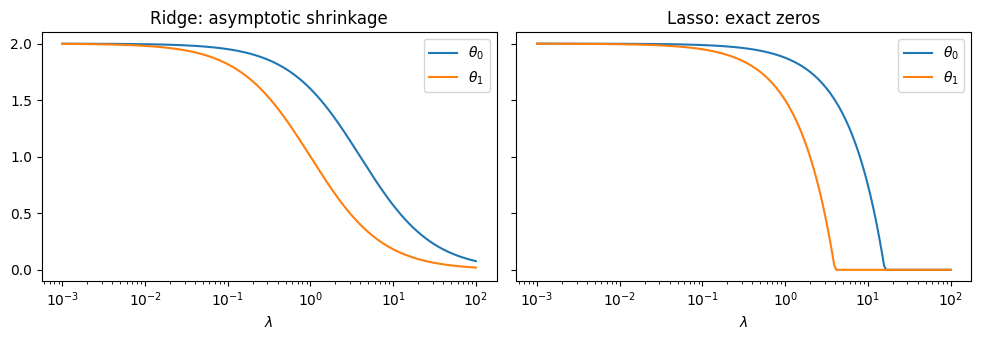

In [9]:
# 1. The toy problem: y = (4,2,3), X diagonal with entries 2, 1
X_toy = np.array([[2.0, 0.0], [0.0, 1.0], [0.0, 0.0]])
y_toy = np.array([4.0, 2.0, 3.0])
n_toy = X_toy.shape[0]
lambdas = np.logspace(-3, 2, 200)

# Conventions: book toy problem uses  ||.||^2 + lambda ||.||  (no 1/n), hence
# alpha = lambda for Ridge and alpha = lambda/(2n) for Lasso.
ridge_path = np.array([Ridge(alpha=l, fit_intercept=False).fit(X_toy, y_toy).coef_
                       for l in lambdas])
lasso_path = np.array([Lasso(alpha=l / (2 * n_toy), fit_intercept=False,
                             max_iter=100000).fit(X_toy, y_toy).coef_
                       for l in lambdas])

ridge_exact = np.column_stack([8.0 / (4.0 + lambdas), 2.0 / (1.0 + lambdas)])
lasso_exact = np.column_stack([np.maximum((16.0 - lambdas) / 8.0, 0.0),
                               np.maximum(2.0 - lambdas / 2.0, 0.0)])
assert np.allclose(ridge_path, ridge_exact) and np.allclose(lasso_path, lasso_exact)
print("analytical and numerical paths agree: Lasso zeros at lambda = 4 and 16")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for k in range(2):
    ax[0].semilogx(lambdas, ridge_path[:, k], label=rf"$\theta_{k}$")
    ax[1].semilogx(lambdas, lasso_path[:, k], label=rf"$\theta_{k}$")
ax[0].set_title("Ridge: asymptotic shrinkage"); ax[1].set_title("Lasso: exact zeros")
for a in ax:
    a.set_xlabel(r"$\lambda$"); a.legend()
plt.tight_layout(); plt.show()

correlation matrix of the standardised columns x, ..., x^5:
[[1.    0.968 0.916 0.865 0.819]
 [0.968 1.    0.986 0.958 0.927]
 [0.916 0.986 1.    0.992 0.975]
 [0.865 0.958 0.992 1.    0.995]
 [0.819 0.927 0.975 0.995 1.   ]]


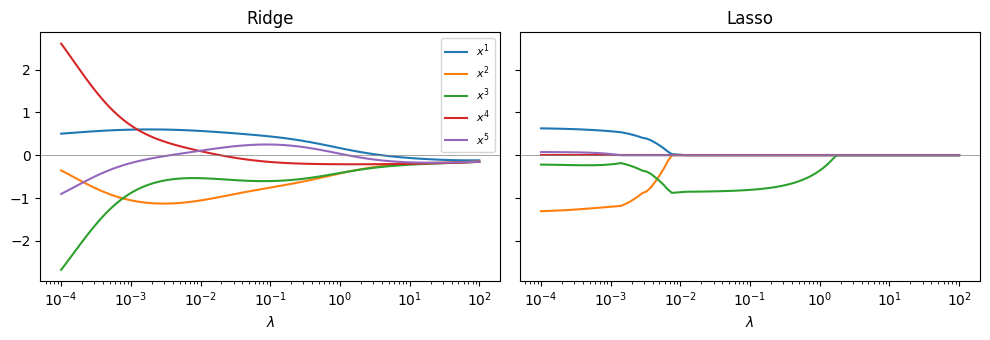

In [10]:
# 2. A correlated design: the columns x^4 and x^5 on [0,1] look almost alike
Xc5 = (X[:, 1:] - X[:, 1:].mean(axis=0)) / X[:, 1:].std(axis=0)
print("correlation matrix of the standardised columns x, ..., x^5:")
print(np.round(np.corrcoef(Xc5.T), 3))

lambdas = np.logspace(-4, 2, 100)
ridge_p = np.array([Ridge(alpha=l, fit_intercept=False).fit(Xc5, yc).coef_
                    for l in lambdas])
lasso_p = np.array([Lasso(alpha=l / 2.0, fit_intercept=False, max_iter=100000)
                    .fit(Xc5, yc).coef_ for l in lambdas])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
labels = [rf"$x^{k}$" for k in range(1, 6)]
for k in range(5):
    ax[0].semilogx(lambdas, ridge_p[:, k], label=labels[k])
    ax[1].semilogx(lambdas, lasso_p[:, k], label=labels[k])
ax[0].set_title("Ridge"); ax[1].set_title("Lasso")
for a in ax:
    a.set_xlabel(r"$\lambda$"); a.axhline(0, color="gray", lw=0.5)
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
# 3. The KKT / optimality check -- the best unit test a Lasso solver has:
#    for every zeroed coefficient j, |(2/n) x_j^T r| <= lambda must hold.
lmbda = 0.05
theta = lasso_cd(Xs, yc, lmbda)
r = yc - Xs @ theta
corr = 2.0 / n * (Xs.T @ r)
for j in range(len(theta)):
    status = "zero   " if abs(theta[j]) < 1e-10 else "active "
    ok = abs(corr[j]) <= lmbda + 1e-8 if abs(theta[j]) < 1e-10 \
         else np.isclose(corr[j], lmbda * np.sign(theta[j]), atol=1e-6)
    print(f"theta_{j+1}: {status} (2/n) x_j.r = {corr[j]:+.5f}   KKT satisfied: {ok}")

theta_1: zero    (2/n) x_j.r = -0.02306   KKT satisfied: True
theta_2: zero    (2/n) x_j.r = -0.04572   KKT satisfied: True
theta_3: active  (2/n) x_j.r = -0.05000   KKT satisfied: True
theta_4: zero    (2/n) x_j.r = -0.04766   KKT satisfied: True
theta_5: zero    (2/n) x_j.r = -0.04320   KKT satisfied: True


**Your turn (Case 3).**

* Which coefficients does the Lasso kill first on the correlated design, and why
  those? Does Ridge ever kill any?
* Duplicate a column of the design (`np.column_stack([Xs, Xs[:, -1]])`) and refit
  both methods. What does Ridge do with the pair? What does the Lasso do? Rerun a
  few times with different noise — is the Lasso's choice stable? Relate to
  Monday's "when the Lasso is the wrong tool" discussion (elastic net).

## Case 4: model selection — the U-curve with and without a penalty

The train/test exercise from the weekly set (Hastie et al., Fig. 2.11), extended:
polynomial degree and $\lambda$ are two dials for the *same* complexity knob.

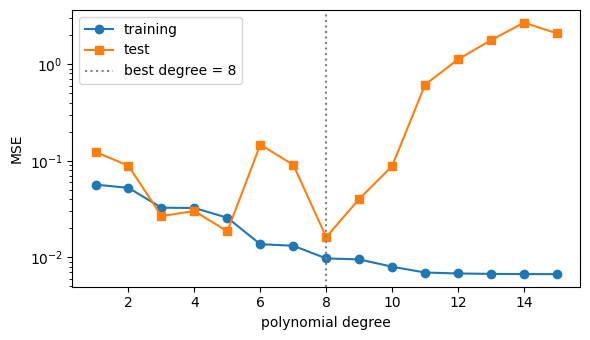

best OLS test MSE 0.01620 at degree 8


In [12]:
from sklearn.model_selection import train_test_split

n4 = 100
x4 = np.linspace(-3, 3, n4)
y4 = np.exp(-x4**2) + 1.5 * np.exp(-(x4 - 2)**2) + rng.normal(0, 0.1, n4)
x_train, x_test, y_train, y_test = train_test_split(x4, y4, test_size=0.3,
                                                    random_state=2026)

# 1. OLS: training and test MSE against polynomial degree
degrees = range(1, 16)
mse_train, mse_test = [], []
for d in degrees:
    Xtr = np.vander(x_train, d + 1, increasing=True)
    Xte = np.vander(x_test,  d + 1, increasing=True)
    theta = np.linalg.lstsq(Xtr, y_train, rcond=None)[0]
    mse_train.append(MSE(y_train, Xtr @ theta))
    mse_test.append(MSE(y_test,  Xte @ theta))

best_d = degrees[int(np.argmin(mse_test))]
plt.figure(figsize=(6, 3.5))
plt.plot(degrees, mse_train, "o-", label="training")
plt.plot(degrees, mse_test, "s-", label="test")
plt.axvline(best_d, color="gray", ls=":", label=f"best degree = {best_d}")
plt.xlabel("polynomial degree"); plt.ylabel("MSE"); plt.yscale("log"); plt.legend()
plt.tight_layout(); plt.show()
print(f"best OLS test MSE {min(mse_test):.5f} at degree {best_d}")

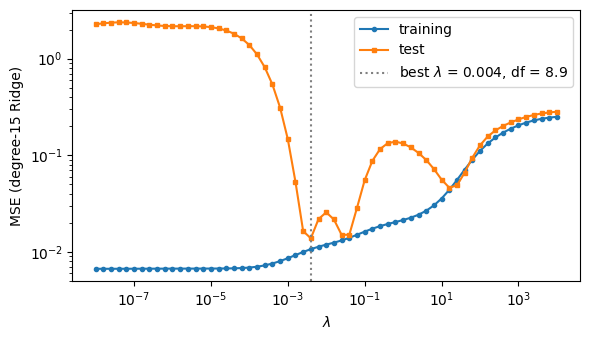

best Ridge test MSE 0.01387 at lambda 0.00398 (effective dof 8.93; best OLS degree above was 8)


In [13]:
# 2. Fix degree 15 and let Ridge's lambda do the model selection instead
d = 15
Xtr = np.vander(x_train, d + 1, increasing=True)
Xte = np.vander(x_test,  d + 1, increasing=True)
# standardise (fit on training data only!), centre y
mu, sd = Xtr[:, 1:].mean(axis=0), Xtr[:, 1:].std(axis=0)
Xtr_s, Xte_s = (Xtr[:, 1:] - mu) / sd, (Xte[:, 1:] - mu) / sd
ym = y_train.mean()

lambdas = np.logspace(-8, 4, 61)
mse_tr_r, mse_te_r, dfs = [], [], []
s = np.linalg.svd(Xtr_s, compute_uv=False)
for l in lambdas:
    theta = ridge_svd(Xtr_s, y_train - ym, l)
    mse_tr_r.append(MSE(y_train, ym + Xtr_s @ theta))
    mse_te_r.append(MSE(y_test,  ym + Xte_s @ theta))
    dfs.append(np.sum(s**2 / (s**2 + l)))          # effective dof

best = int(np.argmin(mse_te_r))
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, mse_tr_r, "o-", ms=3, label="training")
plt.plot(lambdas, mse_te_r, "s-", ms=3, label="test")
plt.axvline(lambdas[best], color="gray", ls=":",
            label=rf"best $\lambda$ = {lambdas[best]:.2g}, df = {dfs[best]:.1f}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$"); plt.ylabel("MSE (degree-15 Ridge)"); plt.legend()
plt.tight_layout(); plt.show()
print(f"best Ridge test MSE {mse_te_r[best]:.5f} at lambda {lambdas[best]:.3g} "
      f"(effective dof {dfs[best]:.2f}; best OLS degree above was {best_d})")

**Your turn (Case 4).**

* Compare the best Ridge test MSE with the best OLS-by-degree test MSE. Which dial
  — degree or $\lambda$ — moves you more smoothly from underfitting to
  overfitting?
* Compare the effective number of parameters
  $\mathrm{df}(\lambda)=\sum_i \sigma_i^2/(\sigma_i^2+\lambda)$ at the best
  $\lambda$ with the best polynomial degree. Coincidence?
* Vary the noise level (0.1 → 0.5) and the number of data points (100 → 30).
  How do the optimal degree and the optimal $\lambda$ move? You are producing the
  experimental data for next week's bias–variance lecture — keep the plots.

**If you finished everything:** check `lasso_cd` against `sklearn` on the
correlated design of Case 3, and implement the elastic net by modifying the
soft-threshold update.

---
## Before you leave

* **Exercise deadline:** Friday at midnight — the analytical matrix–vector
  derivatives, your own OLS code with the `scikit-learn` comparison, and the
  train/test split. Cases 2 and 4 give you most of the code.
* **Keep your functions:** `ridge_svd`, `fit_scaled_unpenalised_intercept` and the
  path plots go straight into Project 1. And keep Case 1's conclusion in mind for
  every penalised fit you ever run: standardise the features, never penalise the
  intercept.
* **Monday next week:** resampling methods (bootstrap, cross-validation) and the
  bias–variance trade-off derived in full.

## Answers to the warm-ups (for the plenary discussion)

**Warm-up 1.** (a) …estimators *linear in $\boldsymbol{y}$ and unbiased* — biased
estimators were never in the competition. (b) …a little bias costs
$O(\lambda^2)$ while the variance falls linearly, so the MSE slope at $\lambda=0$
is strictly negative (Hoerl–Kennard). (c) …set coefficients *exactly* to zero at
finite $\lambda$ — selection, not just shrinkage. (d) …standardised on the
*training data*, with the intercept left unpenalised.

**Warm-up 2.** The trailing singular directions, $\sigma_i^2\ll\lambda$: the
combinations of columns the data barely determine, whose OLS coefficients carry
the largest variance $\sigma^2/\sigma_i^2$. Ridge suppresses first the directions
where the fit is mostly noise — a variance filter ordered by the singular
spectrum.

**Warm-up 3.** $\|\hat{\boldsymbol\theta}\|_2$ strictly decreasing; training MSE
strictly increasing (OLS is the training-MSE minimiser by construction); test MSE
typically U-shaped — falls while variance reduction dominates, rises when bias
takes over. If your test curve does not turn up again, extend the $\lambda$ grid.